# Lab: Regularization in Linear Regression

---

In this lab, we'll learn how to:

* Implement, evaluate, and compare the performance of three regularization techniques for linear regression
* Analyze the effect of simple linear regularization when modelling on noisy data with and without outliers
* Use Lasso regularization to reduce the number of features for subsequent multiple linear regression modelling

Let's start with importing the necessary libraries, defining a function to display evaluation metrics, and generate synthetic data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

In [2]:
def regression_results(y_true, y_pred, regr_type):
    # Regression metrics
    ev = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred) 
    mse = mean_squared_error(y_true, y_pred) 
    r2 = r2_score(y_true, y_pred)
    
    print('Evaluation metrics for ' + regr_type + ' Linear Regression')
    print('explained_variance: ',  round(ev,4)) 
    print('r2: ', round(r2,4))
    print('MAE: ', round(mae,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    print()

In [3]:
# Generate synthetic data
noise = 1
np.random.seed(42)

X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + np.random.randn(1000, 1) * noise
y_ideal = 4 + 3 * X

# Specify the portion of the dataset to add outliers (e.g., the last 20%)
y_outlier = pd.Series(y.reshape(-1).copy())

# Identify indices where the feature variable X is greater than a certain threshold (e.g., 1.5)
threshold = 1.5
outlier_indices = np.where(X.flatten() > threshold)[0]

# Add outliers at random locations within the specified portion
num_outliers = 5
selected_indices = np.random.choice(outlier_indices, size=num_outliers, replace=False)

# Modify the target values at these indices to create outliers (add significant noise)
y_outlier.iloc[selected_indices] += np.random.uniform(50, 100, num_outliers)

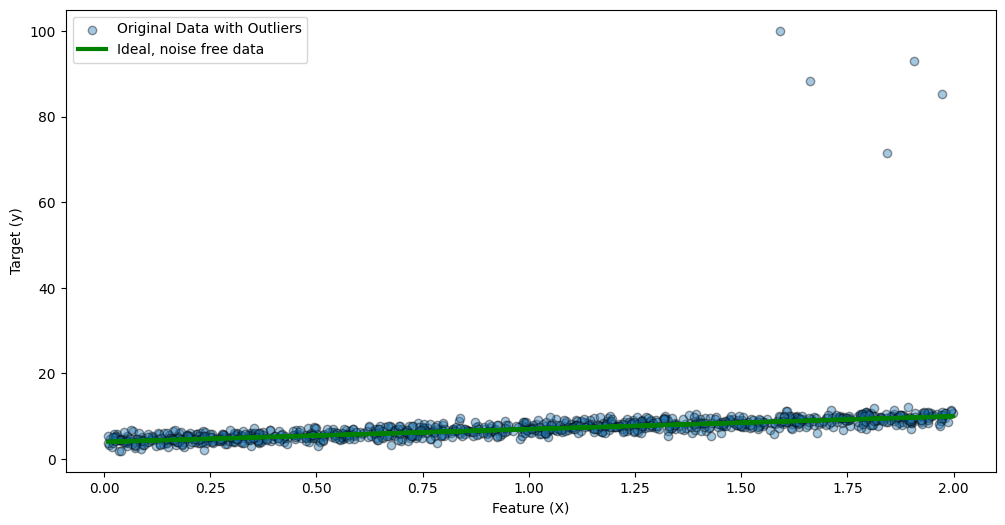

In [4]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y_outlier, alpha=0.4,ec='k', label='Original Data with Outliers')
plt.plot(X, y_ideal,  linewidth=3, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()